# 01 — AAfrag reference check

Reproduces the exact primary spectrum, energy grid, and gamma-ray secondary spectrum from
`aafragpy`'s own published tutorial notebook
([`aafragpy_tutorial.ipynb`](https://github.com/aafragpy/aafragpy/blob/master/aafragpy_tutorial.ipynb)),
fetched directly from GitHub rather than retyped from memory, and confirms that
`aafrag_gammapy.kernel`'s wrapper functions (`cross_section`/`convolve_spectrum`) reproduce
`aafragpy`'s raw `get_cross_section`/`get_spectrum` output *exactly* -- before any gammapy
layer (`aafrag_gammapy.models`) is involved at all.

This is the narrowest possible validation: it only checks that the kernel layer is a
faithful, lossless wrapper around `aafragpy`. Physics validation against independent
codes/composition/neutrino-flavor consistency is covered by notebooks 02-04.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from numpy import log10, sqrt

import aafragpy
from aafrag_gammapy import kernel

%matplotlib inline

## Tutorial's primary spectrum

Verbatim from the tutorial: a power law in momentum with slope $\Gamma=-2$ and an
exponential cutoff at $p_0 = 10^5$ GeV, restricted to primary energies above the tutorial's
own "threshold" $E_\mathrm{thr} = 4$ GeV (this matches `kernel.energy_range("p", "p",
"gam")`'s own lower threshold exactly, confirming ADR-018's live-query approach agrees with
the tutorial's hardcoded value).

One deliberate deviation from the tutorial: the tutorial passes an explicit
`E_secondaries=E_s` binning to `get_cross_section`. `kernel.cross_section` never does this
(ADR-014: it always uses `aafragpy`'s own default ~1600-point secondary grid, which is what
lets `combine_species` sum contributions from different species pairs without
interpolating). So the comparison below also omits `E_secondaries`, to compare like-for-like
against what `kernel.py` actually calls -- this changes only the secondary-energy binning
the result is reported on, not the underlying physics.

In [2]:
m_p = 0.938  # proton rest energy in GeV
Gamma = -2.0  # spectral slope
p_0 = 1e5  # cutoff energy, GeV
E_thr = 4  # "threshold" energy in GeV, tutorial's own value

E_p = np.logspace(0, 10, 100)  # primary energies, GeV -- 10 bins/decade
p_p = sqrt(E_p**2 - m_p**2)  # primary momenta, GeV
dNp_dEp = p_p**Gamma * np.exp(-p_p / p_0) * E_p / p_p  # dN/dE_p (via dN/dp * dp/dE)

lo, hi = kernel.energy_range("p", "p", "gam")
print(f"kernel.energy_range('p', 'p', 'gam') = ({lo}, {hi}) GeV -- tutorial uses E_thr={E_thr}")
assert lo == E_thr

kernel.energy_range('p', 'p', 'gam') = (4.0, 396868075520.0) GeV -- tutorial uses E_thr=4


## Raw `aafragpy` output (the tutorial's own reference)

Same call as tutorial cells 10/13 (gamma-ray channel, p-p interaction, restricted to
$E_p > E_\mathrm{thr}$), minus the explicit `E_secondaries` binning per the note above. Uses
`e_primary_ref` (the primary-energy grid `get_cross_section` itself returns) rather than the
literal `E_p[mask]` input when calling `get_spectrum` -- `aafragpy` returns its own
internally-reprocessed copy of the requested grid, which differs from the literal input at
the ~1e-15 relative (floating-point-noise) level; feeding `get_spectrum` anything else
introduces exactly that noise into the comparison, which would make an otherwise-exact
wrapper look inexact for a reason that has nothing to do with `kernel.py`.

In [3]:
mask = E_p > E_thr
cs_matrix, e_primary_ref, e_secondary_ref = aafragpy.get_cross_section(
    "gam", "p-p", E_primaries=E_p[mask]
)
spec_reference = aafragpy.get_spectrum(
    e_primary_ref, e_secondary_ref, cs_matrix=cs_matrix, prim_spectrum=dNp_dEp[mask]
)

## Same computation through `aafrag_gammapy.kernel`

`kernel.cross_section` wraps `get_cross_section` (memoized); `kernel.convolve_spectrum`
wraps `get_spectrum`. Same inputs, same channel/species, same primary energy grid.

In [4]:
cs = kernel.cross_section("p", "p", "gam", E_p[mask])
spec_kernel = kernel.convolve_spectrum(cs, dNp_dEp[mask])

np.testing.assert_array_equal(cs.matrix, cs_matrix)
np.testing.assert_array_equal(cs.energy_secondary, e_secondary_ref)
np.testing.assert_array_equal(spec_kernel, spec_reference)
print("kernel.py reproduces aafragpy's raw get_cross_section/get_spectrum output exactly.")

kernel.py reproduces aafragpy's raw get_cross_section/get_spectrum output exactly.


## Reference plot

Reproduces the tutorial's own plot (cell 14: $E_s^2 \, dN/dE_s$ vs $E_s$, same axis
limits) using the kernel-wrapped spectrum, to visually confirm the expected pion-bump shape
peaking around the pion rest mass scale.

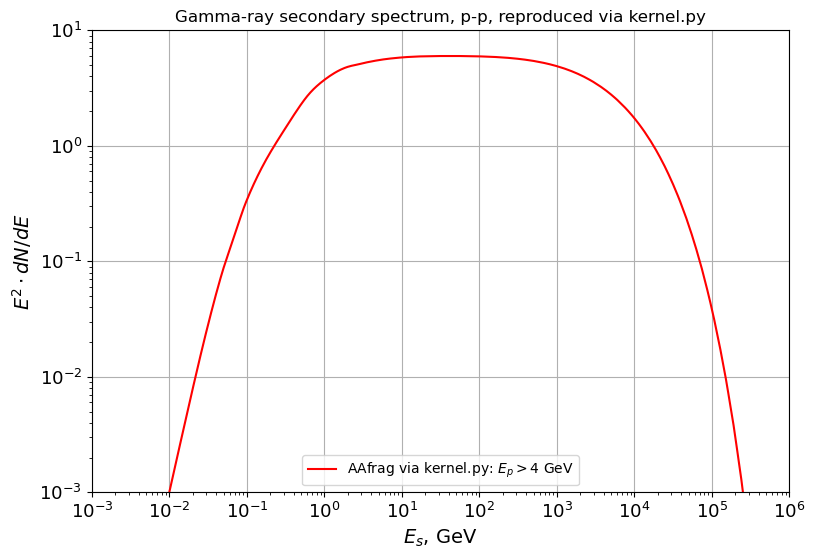

In [5]:
E_s = cs.energy_secondary
plt.figure(figsize=(9, 6))
plt.loglog(E_s, spec_kernel * E_s**2, "r-", label=f"AAfrag via kernel.py: $E_p > {E_thr}$ GeV")
plt.tick_params(axis="both", which="major", labelsize=13)
plt.grid()
plt.xlabel(r"$E_s$, GeV", fontsize=14)
plt.ylabel(r"$E^2 \cdot dN/dE$", fontsize=14)
plt.ylim(1e-3, 1e1)
plt.xlim(1e-3, 1e6)
plt.legend()
plt.title("Gamma-ray secondary spectrum, p-p, reproduced via kernel.py")
plt.show()

## Conclusion

`aafrag_gammapy.kernel`'s `cross_section`/`convolve_spectrum` wrappers reproduce
`aafragpy`'s own tutorial reference spectrum bit-for-bit (`np.testing.assert_array_equal`,
not just `allclose`), confirming the kernel layer performs no lossy transformation before
handing off to `models.py`. This validates ADR-003's kernel/model split boundary: any
physics discrepancy found in notebooks 02-04 must come from `models.py`'s combination logic
or physical conventions (ADR-018/019), not from a broken `aafragpy` wrapper.